In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from var_assim.plotting.presets import get_presets
from var_assim.plotting.utils import make_figure_filename
from var_assim.config import DATA_DIR_ABS, FIGS_DIR

presets, _ = get_presets()
plt.rcParams.update(presets)

# enable auto reload
%load_ext autoreload
%autoreload 2

In [2]:
model = 'pco2geowc_reg'
git = '86974a5_20260731T123841'

adj_df = pd.read_csv(DATA_DIR_ABS / 'checks' / model / git / 'adj_id_check.csv')
grad_df = pd.read_csv(DATA_DIR_ABS / 'checks' / model / git / 'cost_grad_check.csv')
tlm_df = pd.read_csv(DATA_DIR_ABS / 'checks' / model / git / 'tlm_check.csv')

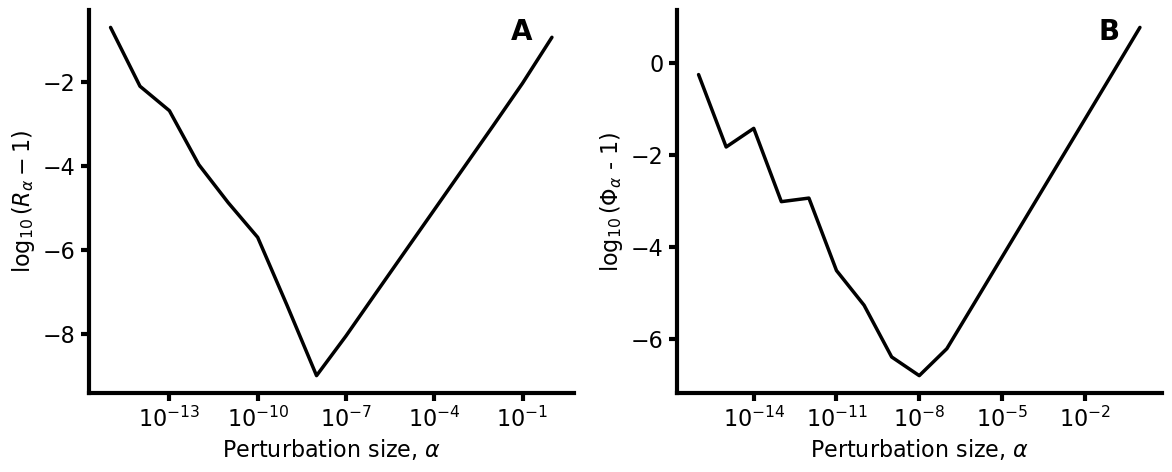

In [3]:
fig, ax = plt.subplot_mosaic([['A', 'B']], figsize=(12, 5))

ax['A'].semilogx(tlm_df['perturbation_size'], tlm_df['log(|norms - 1|)'])
ax['B'].semilogx(grad_df['perturbation_size'], grad_df['log(phi - 1)'])

ax['A'].set_ylabel(r"$\log_{10}(R_{\alpha} - 1)$")
ax['A'].set_xlabel(r"Perturbation size, $\alpha$")

ax['B'].set_ylabel(r"$\log_{10}(\Phi_{\alpha}$ - 1)")
ax['B'].set_xlabel(r"Perturbation size, $\alpha$")

# set panel labels
for label in ax.keys():
    ax[label].text(
        0.87,
        0.98,
        label,
        transform=ax[label].transAxes,
        fontsize=20,
        fontweight="bold",
        va="top",
        ha="left",
    )

fig.tight_layout()

plt.savefig(
    make_figure_filename('tlm-grad-check', FIGS_DIR / 'checks'),
    dpi=300, bbox_inches='tight'
)
plt.show()

In [43]:
ax

{'A': <Axes: label='A', xlabel='Perturbation size, $\\alpha$', ylabel='$\\log_{10}(R_{\\alpha} - 1)$'>,
 'B': <Axes: label='B', xlabel='Perturbation size, $\\alpha$', ylabel='$\\log_{10}(\\Phi_{\\alpha}$ - 1)'>}